In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ── PyTorch core ──────────────────────────────────────────────────────────────
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch

# ── TorchVision ───────────────────────────────────────────────────────────────
import torchvision.transforms as transforms
from torchvision.models import inception_v3,resnet50,efficientnet_b4,EfficientNet_B4_Weights,ResNet50_Weights,Inception_V3_Weights
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

# ── Data utilities ────────────────────────────────────────────────────────────
# from torch.utils.data import random_split
from torch.utils.data.dataloader import DataLoader
from sklearn.utils import shuffle
from tqdm import tqdm                                       # progress bars for training loop

# ── Evaluation ────────────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report,f1_score,roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:

TRAIN_PATH = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\mrl-eye-dataset\train"
VAL_PATH = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\mrl-eye-dataset\val"
TEST_PATH = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\mrl-eye-dataset\test"

SIZE = 256
CROP_SIZE = 224

BATCH_SIZE = 64
EPOCHS = 30
PATIENCE = 5

LR  = 1e-4


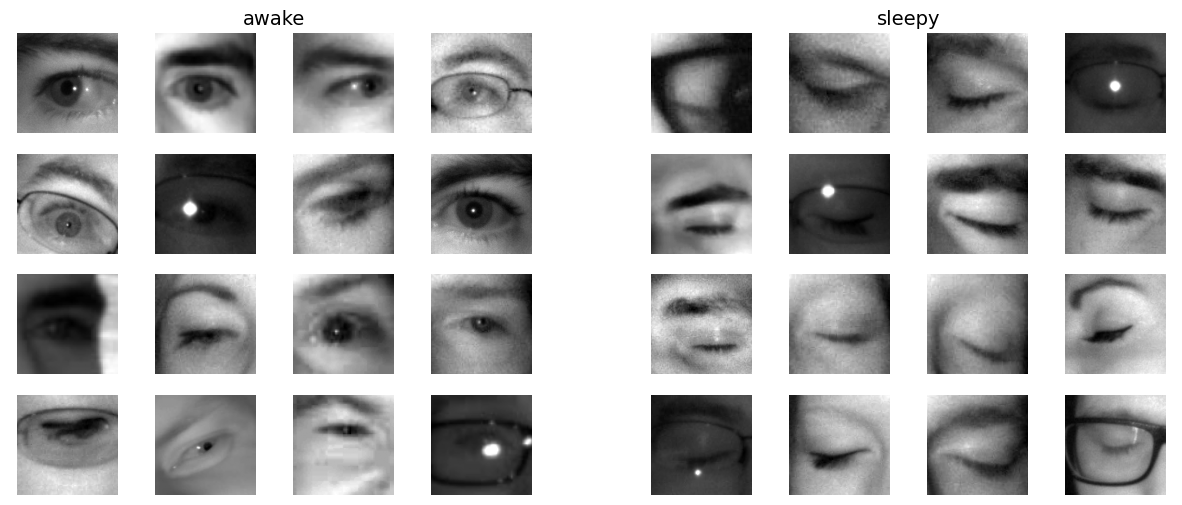

In [42]:
def show_random_image(PATH, num_of_samples=16):
    labels = os.listdir(PATH)

    fig = plt.figure(figsize=(15, 6))

    
    outer = fig.add_gridspec(1, 2, wspace=0.2)

    for j, label_name in enumerate(labels[:2]):
        label_path = os.path.join(PATH, label_name)
        images = shuffle(os.listdir(label_path))[:num_of_samples]

        
        inner = outer[j].subgridspec(4, 4)

        
        ax_title = fig.add_subplot(outer[j])
        ax_title.set_title(label_name, fontsize=14)
        ax_title.axis("off")

        for i, img_name in enumerate(images):
            r, c = divmod(i, 4)
            ax = fig.add_subplot(inner[r, c])
            img_path = os.path.join(label_path, img_name)
            ax.imshow(plt.imread(img_path), cmap="gray")
            ax.axis("off")

    plt.show()

show_random_image(TRAIN_PATH)

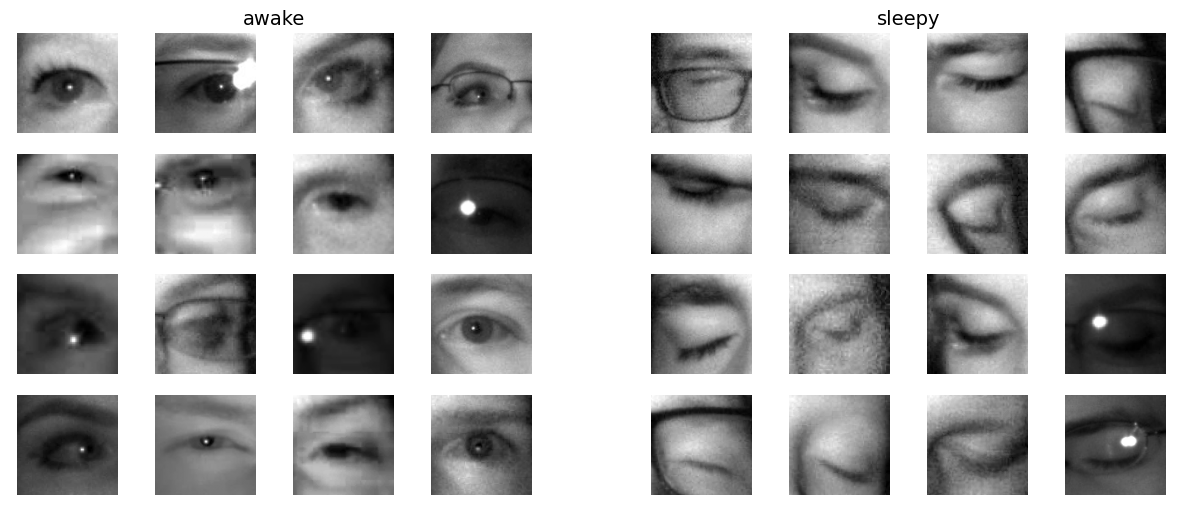

In [43]:
show_random_image(VAL_PATH)

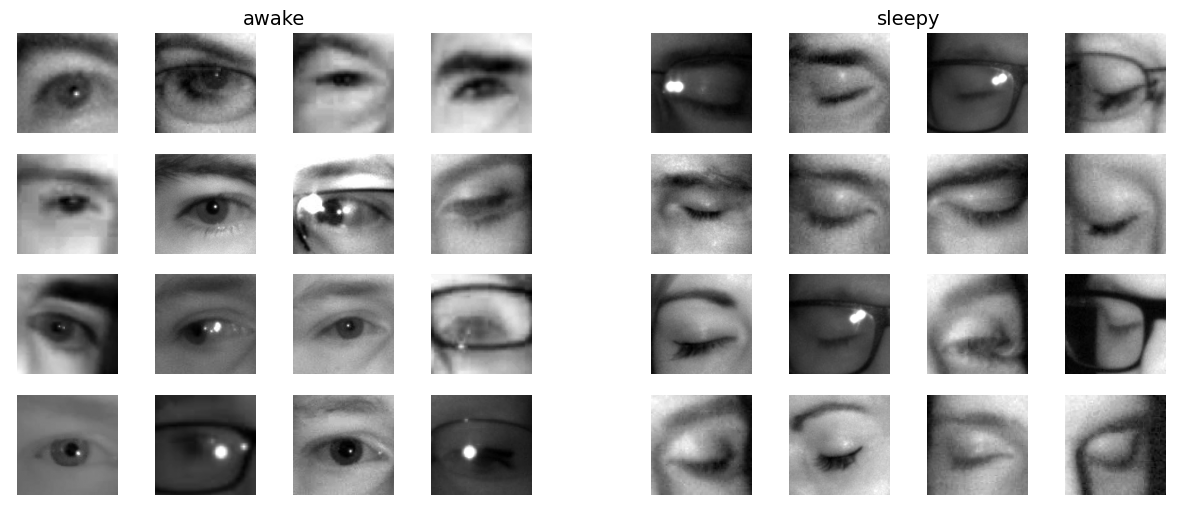

In [44]:
show_random_image(TEST_PATH)